# <span style='color:Red'>Main effect analysis (graphs)</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, re, ast, seaborn, jlib
from matplotlib import pyplot

saveFigs = True
imagePath = 'img/main/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

minAccuracyValue = 0
maxAccuracyValue = 1.2

minErrorOverBlocksValue = 0
maxErrorOverBlocksValue = 70

significanceSize = 14

desiredEffectSize = 'ges'

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}
paletteInformative = {'Chunkable':'#7ca3cc','Non-chunkable':'#d68e5d'}
paletteUninformative = {'Chunkable':'#c7f0ff','Non-chunkable':'#ffdba8'}
paletteIUCombined = {'Chunkable\nInformative':"#7ca3cc",'Non-chunkable\nInformative':"#d68e5d",
                     'Chunkable\nUninformative':"#c7f0ff",'Non-chunkable\nUninformative':"#ffdba8"}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp4Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path','Continuous target',
                         'Target','Mean target'],axis=1,inplace=True)

## <span style='color:Red'>Main effects of chunking</span>

In [2]:
errNoCueDataOverTime = allParticipantData.copy()
errNoCueDataOverTime.drop(columns=['Cue type'],inplace=True)
errNoCueDataOverTime = errNoCueDataOverTime.groupby(['Subject','Trial type','Block']).median().reset_index()

errNoCueData = allParticipantData.copy()
errNoCueData.drop(columns=['Cue type'],inplace=True)
errNoCueData = errNoCueData.groupby(['Subject','Trial type']).median().reset_index()

accNoCueDataOverTime = allParticipantData.copy()
accNoCueDataOverTime.drop(columns=['Cue type'],inplace=True)
accNoCueDataOverTime = accNoCueDataOverTime.groupby(['Subject','Trial type','Block']).mean().reset_index()

accNoCueData = allParticipantData.copy()
accNoCueData.drop(columns=['Cue type'],inplace=True)
accNoCueData = accNoCueData.groupby(['Subject','Trial type']).mean().reset_index()

In [3]:
errNCTrial = errNoCueData.loc[errNoCueData['Trial type']=='Non-chunkable',
                              :]['Response error (absolute)'].to_numpy()
errCTrial = errNoCueData.loc[errNoCueData['Trial type']=='Chunkable',
                             :]['Response error (absolute)'].to_numpy()

errChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=errNCTrial,
                                                          column2=errCTrial,
                                                          isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                          effectSize=True,descriptives=True)

errChunkingTtestPS['ttest'].columns = errChunkingTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSErrChunkingEffect",
                            jlib.data.constants.extractWilcoxonResults(errChunkingTtestPS['ttest'],0))

errChunkingTtestPS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  293.0  0.000001   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.953333  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.839789  0.001421,
 'descriptives':          name  num          m        med        sd        se
 "set11"  set1   24  23.991616  23.537621  8.944652  1.825819
 "set21"  set2   24  16.913508  14.491911  6.699668  1.367564}

In [4]:
accNCTrial = accNoCueData.loc[accNoCueData['Trial type']=='Non-chunkable',
                              :]['Accuracy'].to_numpy()
accCTrial = accNoCueData.loc[accNoCueData['Trial type']=='Chunkable',
                             :]['Accuracy'].to_numpy()

accChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=accCTrial,
                                                          column2=accNCTrial,
                                                          isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                          effectSize=True,descriptives=True)

accChunkingTtestPS['ttest'].columns = accChunkingTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSAccChunkingEffect",
#                             jlib.data.constants.extractTtestResults(accChunkingTtestPS['ttest'],0))

accChunkingTtestPS

{'ttest':                            var1  var2           te      sta    df  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  6.66461  23.0   
 
                                       p     esType         e  
 {"i1":"set1","i2":"set2"}  4.230124e-07  Cohen's d  1.360408  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.931788  0.106888,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.611704  0.616992  0.147296  0.030067
 "set21"  set2   24  0.452981  0.443941  0.088765  0.018119}

## <span style='color:Red'>Continuous error (absolute)</span>

### <span style='color:Red'>Error over blocks</span>

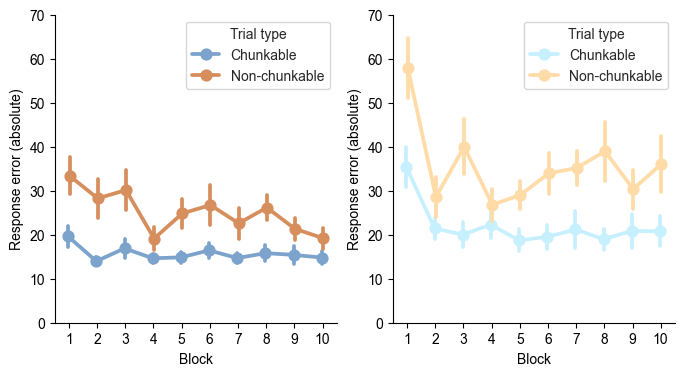

In [5]:
angleColumns = ['Response error (absolute)']

errOverTime = allParticipantData.copy()
errOverTime = errOverTime.groupby(['Subject','Block','Trial type','Cue type'])[angleColumns].apply(
    lambda x: pandas.Series({col: numpy.median(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots(1,2,figsize=(8,4))
seaborn.set_style('ticks')
seaborn.pointplot(ax=ax[0],
                  data=errOverTime.loc[errOverTime['Cue type']=='Informative',:],
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteInformative)
ax[0].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)

seaborn.pointplot(ax=ax[1],
                  data=errOverTime.loc[errOverTime['Cue type']=='Uninformative',:],
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteUninformative)
ax[1].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)

seaborn.despine()

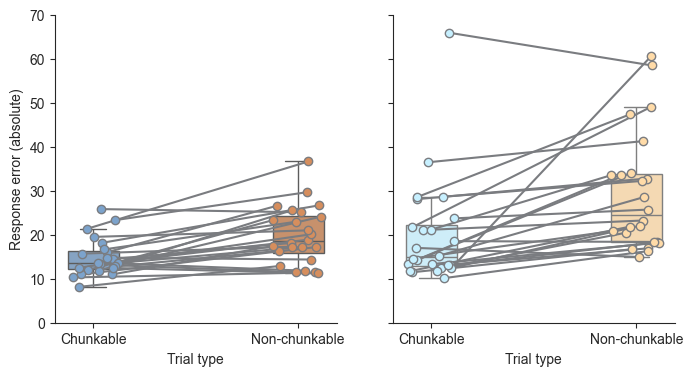

In [6]:
medianGroupedData = allParticipantData.copy()
medianGroupedData = medianGroupedData.groupby(['Subject','Trial type','Cue type']).median().reset_index()

fig,ax = pyplot.subplots(1,2,figsize=(8,4),sharey=True)
jlib.display.pairedObs.boxPlotPaired(ax=ax[0],
                                     data=medianGroupedData.loc[medianGroupedData['Cue type']=='Informative',:],
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteInformative)
ax[0].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)

jlib.display.pairedObs.boxPlotPaired(ax=ax[1],
                                     data=medianGroupedData.loc[medianGroupedData['Cue type']=='Uninformative',:],
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteUninformative)
ax[1].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)

seaborn.despine()

### <span style='color:Red'>ANOVA (chunking effect + cue effect)</span>

In [7]:
errCTrialICueData = medianGroupedData[(medianGroupedData['Cue type']=='Informative') &
                                      (medianGroupedData['Trial type']=='Chunkable')]['Response error (absolute)'].to_numpy()
errNCTrialICueData = medianGroupedData[(medianGroupedData['Cue type']=='Informative') &
                                       (medianGroupedData['Trial type']=='Non-chunkable')]['Response error (absolute)'].to_numpy()

errCTrialUCueData = medianGroupedData[(medianGroupedData['Cue type']=='Uninformative') &
                                      (medianGroupedData['Trial type']=='Chunkable')]['Response error (absolute)'].to_numpy()
errNCTrialUCueData = medianGroupedData[(medianGroupedData['Cue type']=='Uninformative') &
                                         (medianGroupedData['Trial type']=='Non-chunkable')]['Response error (absolute)'].to_numpy()

nParticipants = numpy.unique(medianGroupedData['Subject']).shape[0]
mapValueHandler.setKeyValue("errorCTrialICueMSE",
                            f"$M={numpy.mean(errCTrialICueData):.2f}, SE={numpy.std(errCTrialICueData)/numpy.sqrt(nParticipants):.2f}$")
mapValueHandler.setKeyValue("errorCTrialUCueMSE",
                            f"$M={numpy.mean(errCTrialUCueData):.2f}, SE={numpy.std(errCTrialUCueData)/numpy.sqrt(nParticipants):.2f}$")
mapValueHandler.setKeyValue("errorNCTrialICueMSE",
                            f"$M={numpy.mean(errNCTrialICueData):.2f}, SE={numpy.std(errNCTrialICueData)/numpy.sqrt(nParticipants):.2f}$")
mapValueHandler.setKeyValue("errorNCTrialUCueMSE",
                            f"$M={numpy.mean(errNCTrialUCueData):.2f}, SE={numpy.std(errNCTrialUCueData)/numpy.sqrt(nParticipants):.2f}$")

errChunkingCueDF = pandas.DataFrame({'Subject':numpy.unique(medianGroupedData['Subject']),
                                     'ChunkableCue1Err':errCTrialICueData,
                                     'ChunkableCue2Err':errCTrialUCueData,
                                     'NonChunkableCue1Err':errNCTrialICueData,
                                     'NonChunkableCue2Err':errNCTrialUCueData})

errChunkingCueAnovaRM = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                                    data=errChunkingCueDF,
                                                    rmLabels=['Trial','Cue'],
                                                    rmLists=[['Chunkable','NonChunkable'],[1,2]],
                                                    rmMeasureName='Err',
                                                    rmTerms='~Cue+Trial+Cue:Trial',
                                                    effectSize=[desiredEffectSize])

errChunkingCueAnovaRM['within'].columns = errChunkingCueAnovaRM['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaErrVsCue",
                            jlib.data.constants.extractAnovaResults(errChunkingCueAnovaRM['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaErrVsChunking",
                            jlib.data.constants.extractAnovaResults(errChunkingCueAnovaRM['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaErrVsCueChunking",
                            jlib.data.constants.extractAnovaResults(errChunkingCueAnovaRM['within'],
                                                                    4,5,desiredEffectSize))

errChunkingCueAnovaRM

{'within':                               nam           ss    df           ms          F  \
 "Cue"                         Cue  1285.565469   1.0  1285.565469  17.151107   
 ["Cue",".RES"]           Residual  1723.970669  23.0    74.955246        NaN   
 "Trial"                     Trial  1283.079063   1.0  1283.079063  23.798408   
 ["Trial",".RES"]         Residual  1240.033319  23.0    53.914492        NaN   
 ["Cue","Trial"]         Cue:Trial   114.559764   1.0   114.559764   5.046637   
 ["Cue","Trial",".RES"]   Residual   522.104989  23.0    22.700217        NaN   
 
                                p       ges  
 "Cue"                   0.000396  0.127085  
 ["Cue",".RES"]               NaN       NaN  
 "Trial"                 0.000063  0.126870  
 ["Trial",".RES"]             NaN       NaN  
 ["Cue","Trial"]         0.034573  0.012807  
 ["Cue","Trial",".RES"]       NaN       NaN  ,
 'between':                 name           ss    df          ms           F           p  \
 "Resid

### <span style='color:Red'>T-test (informative cue, chunking effect)</span>

In [8]:
errICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=errNCTrialICueData,
                                                      column2=errCTrialICueData,
                                                      isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

errICueTtestPS['ttest'].columns = errICueTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSErrInformativeTrialsChunkingEffect",
                            jlib.data.constants.extractWilcoxonResults(errICueTtestPS['ttest'],0,2))

errICueTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  279.0  0.000027   
 
                                               esType    es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.86  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.956655  0.374971,
 'descriptives':          name  num          m        med        sd       se
 "set11"  set1   24  19.888442  18.493472  6.501337  1.32708
 "set21"  set2   24  14.761490  13.488330  4.236639  0.86480}

### <span style='color:Red'>T-test (uninformative cue, chunking effect)</span>

In [9]:
errUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=errNCTrialUCueData,
                                                      column2=errCTrialUCueData,
                                                      isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

errUCueTtestPS['ttest'].columns = errUCueTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSErrUninformativeTrialsChunkingEffect",
                            jlib.data.constants.extractWilcoxonResults(errUCueTtestPS['ttest'],0,2))

errUCueTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  282.0  0.000015   
 
                                               esType    es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.88  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.838256  0.001334,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  29.392063  24.471534  13.404231  2.736127
 "set21"  set2   24  19.895523  14.902603  12.001436  2.449783}

### <span style='color:Red'>T-test (chunkable trials, cue effect)</span>

In [10]:
errCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        column1=errCTrialUCueData,
                                                        column2=errCTrialICueData,
                                                        isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                        effectSize=True,descriptives=True)

errCTrialTtestPS['ttest'].columns = errCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSErrChunkableTrialsCueEffect",
                            jlib.data.constants.extractWilcoxonResults(errCTrialTtestPS['ttest'],0,2))

errCTrialTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  268.0  0.000161   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.786667  ,
 'normality':                            var1 sep  var2        w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.66918  0.000004,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  19.895523  14.902603  12.001436  2.449783
 "set21"  set2   24  14.761490  13.488330   4.236639  0.864800}

### <span style='color:Red'>T-test (non-chunkable trials, cue effect)</span>

In [11]:
errNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                         column1=errNCTrialUCueData,
                                                         column2=errNCTrialICueData,
                                                         isStudent=False,isWilcoxon=True,hypothesis='oneGreater',
                                                         effectSize=True,descriptives=True)

errNCTrialTtestPS['ttest'].columns = errNCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSErrNonchunkableTrialsCueEffect",
                            jlib.data.constants.extractWilcoxonResults(errNCTrialTtestPS['ttest'],0,2))

errNCTrialTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  278.0  0.000032   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.853333  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.915369  0.046186,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  29.392063  24.471534  13.404231  2.736127
 "set21"  set2   24  19.888442  18.493472   6.501337  1.327080}

### <span style='color:Red'>Sensitivity test: interaction</span>

In [12]:
errInteractionTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                             column1=errNCTrialUCueData-errNCTrialICueData,
                                                             column2=errCTrialUCueData-errCTrialICueData,
                                                             isStudent=False,isWilcoxon=True,hypothesis='different',
                                                             effectSize=True,descriptives=True)

errInteractionTtestPS['ttest'].columns = errInteractionTtestPS['ttest'].columns.str.rstrip('[wilc]')

errInteractionTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  225.0  0.031482   
 
                                               esType   es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.5  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.874335  0.006404,
 'descriptives':          name  num         m       med         sd        se
 "set11"  set1   24  9.503621  6.516112  10.771015  2.198624
 "set21"  set2   24  5.134033  1.701082   8.904840  1.817693}

### <span style='color:Red'>Sensitivity test: main effect of chunking</span>

In [13]:
errChunkingTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=0.5*(errNCTrialUCueData+errNCTrialICueData),
                                                          column2=0.5*(errCTrialUCueData+errCTrialICueData),
                                                          isStudent=False,isWilcoxon=True,hypothesis='different',
                                                          effectSize=True,descriptives=True)

errChunkingTtestPS['ttest'].columns = errChunkingTtestPS['ttest'].columns.str.rstrip('[wilc]')

errChunkingTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  290.0  0.000005   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.933333  ,
 'normality':                            var1 sep  var2        w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.88592  0.010957,
 'descriptives':          name  num          m        med        sd        se
 "set11"  set1   24  24.640253  25.610114  9.053547  1.848047
 "set21"  set2   24  17.328507  14.540169  7.820982  1.596451}

### <span style='color:Red'>Sensitivity test: main effect of cue</span>

In [14]:
errCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                     column1=0.5*(errNCTrialUCueData+errCTrialUCueData),
                                                     column2=0.5*(errNCTrialICueData+errCTrialICueData),
                                                     isStudent=False,isWilcoxon=True,hypothesis='different',
                                                     effectSize=True,descriptives=True)

errCueTtestPS['ttest'].columns = errCueTtestPS['ttest'].columns.str.rstrip('[wilc]')

errCueTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  281.0  0.000037   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.873333  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.850569  0.00224,
 'descriptives':          name  num          m        med         sd        se
 "set11"  set1   24  24.643793  22.013076  11.382826  2.323510
 "set21"  set2   24  17.324966  16.299517   4.907761  1.001792}

## <span style='color:Red'>Results: accuracy (all subjects)</span>

### <span style='color:Red'>Accuracy over blocks</span>

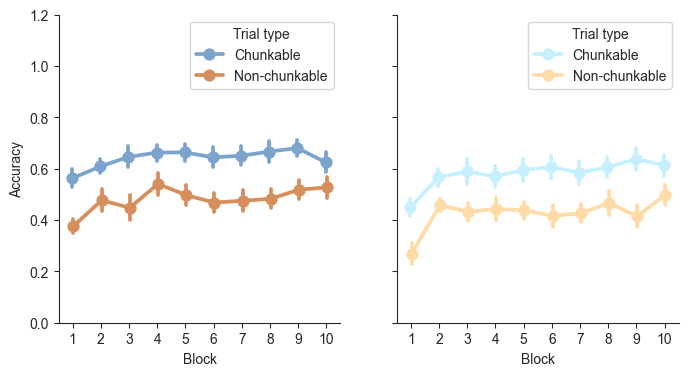

In [15]:
fig,ax = pyplot.subplots(1,2,figsize=(8,4),sharey=True)
seaborn.set_style('ticks')
seaborn.pointplot(ax=ax[0],
                  data=allParticipantData.loc[allParticipantData['Cue type']=='Informative',
                                              :].groupby(['Subject','Block',
                                                          'Trial type','Cue type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteInformative)
ax[0].set_ylim(minAccuracyValue,maxAccuracyValue)

seaborn.pointplot(ax=ax[1],
                  data=allParticipantData.loc[allParticipantData['Cue type']=='Uninformative',
                                              :].groupby(['Subject','Block',
                                                          'Trial type','Cue type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteUninformative)
ax[1].set_ylim(minAccuracyValue,maxAccuracyValue)

seaborn.despine()

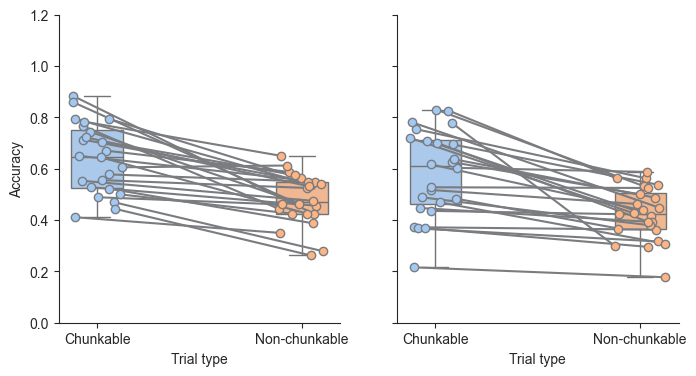

In [16]:
fig,ax = pyplot.subplots(1,2,figsize=(8,4),sharey=True)
jlib.display.pairedObs.boxPlotPaired(ax=ax[0],
                                     data=allParticipantData.loc[allParticipantData['Cue type']=='Informative',
                                                                 :].groupby(['Subject','Trial type',
                                                                             'Cue type']).mean().reset_index(),
                                     x='Trial type',y='Accuracy',
                                     width=0.25,palette=seaborn.color_palette('pastel',2))
ax[0].set_ylim(minAccuracyValue,maxAccuracyValue)

jlib.display.pairedObs.boxPlotPaired(ax=ax[1],
                                     data=allParticipantData.loc[allParticipantData['Cue type']=='Uninformative',
                                                                 :].groupby(['Subject','Trial type',
                                                                             'Cue type']).mean().reset_index(),
                                     x='Trial type',y='Accuracy',
                                     width=0.25,palette=seaborn.color_palette('pastel',2))
ax[1].set_ylim(minAccuracyValue,maxAccuracyValue)

seaborn.despine()

### <span style='color:Red'>T-test (informative cue, chunking effect)</span>

In [17]:
meanGroupedData = allParticipantData.copy()
meanGroupedData = meanGroupedData.groupby(['Subject','Trial type','Cue type']).mean().reset_index()

accCTrialICueData = meanGroupedData[(meanGroupedData['Cue type']=='Informative') &
                                    (meanGroupedData['Trial type']=='Chunkable')]['Accuracy'].to_numpy()
accNCTrialICueData = meanGroupedData[(meanGroupedData['Cue type']=='Informative') &
                                     (meanGroupedData['Trial type']=='Non-chunkable')]['Accuracy'].to_numpy()

accICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=accCTrialICueData,
                                                      column2=accNCTrialICueData,
                                                      isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

accICueTtestPS['ttest'].columns = accICueTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSAccInformativeTrialsChunkingEffect",
#                             jlib.data.constants.extractTtestResults(accICueTtestPS['ttest'],0,2))

accICueTtestPS

{'ttest':                            var1  var2           te       sta    df  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  6.567453  23.0   
 
                                       p     esType         e  
 {"i1":"set1","i2":"set2"}  5.302287e-07  Cohen's d  1.340576  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.935285  0.127989,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.641119  0.647222  0.136537  0.027871
 "set21"  set2   24  0.480757  0.470833  0.097902  0.019984}

### <span style='color:Red'>T-test (uninformative cue, chunking effect)</span>

In [18]:
accCTrialUCueData = meanGroupedData[(meanGroupedData['Cue type']=='Uninformative') &
                                    (meanGroupedData['Trial type']=='Chunkable')]['Accuracy'].to_numpy()
accNCTrialUCueData = meanGroupedData[(meanGroupedData['Cue type']=='Uninformative') &
                                     (meanGroupedData['Trial type']=='Non-chunkable')]['Accuracy'].to_numpy()

accUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=accCTrialUCueData,
                                                      column2=accNCTrialUCueData,
                                                      isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                      effectSize=True,descriptives=True)

accUCueTtestPS['ttest'].columns = accUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSAccUninformativeTrialsChunkingEffect",
#                             jlib.data.constants.extractTtestResults(accUCueTtestPS['ttest'],0,2))

accUCueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  6.054479  23.0  0.000002   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.235865  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.919309  0.056391,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.582093  0.610009  0.167563  0.034204
 "set21"  set2   24  0.424958  0.424872  0.102307  0.020883}

### <span style='color:Red'>T-test (chunkable trials, cue effect)</span>

In [19]:
accCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                        column1=accCTrialICueData,
                                                        column2=accCTrialUCueData,
                                                        isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                        effectSize=True,descriptives=True)

accCTrialTtestPS['ttest'].columns = accCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSAccChunkableTrialsCueEffect",
#                             jlib.data.constants.extractTtestResults(accCTrialTtestPS['ttest'],0,2))

accCTrialTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.583539  23.0  0.000786   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.731487  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.920145  0.058841,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.641119  0.647222  0.136537  0.027871
 "set21"  set2   24  0.582093  0.610009  0.167563  0.034204}

### <span style='color:Red'>T-test (unchunkable trials, cue effect)</span>

In [20]:
accNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                         column1=accNCTrialICueData,
                                                         column2=accNCTrialUCueData,
                                                         isStudent=True,isWilcoxon=False,hypothesis='oneGreater',
                                                         effectSize=True,descriptives=True)

accNCTrialTtestPS['ttest'].columns = accNCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSAccUnchunkableTrialsCueEffect",
#                             jlib.data.constants.extractTtestResults(accNCTrialTtestPS['ttest'],0,2))

accNCTrialTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  2.961462  23.0  0.003497   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.604506  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.952056  0.300029,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  0.480757  0.470833  0.097902  0.019984
 "set21"  set2   24  0.424958  0.424872  0.102307  0.020883}

### <span style='color:Red'>ANOVA (chunking effect + cue effect)</span>

In [21]:
chunkingCueAccDF = pandas.DataFrame({'Subject':numpy.unique(allParticipantData['Subject']),
                                     'ChunkableCue1Acc':accCTrialICueData,
                                     'ChunkableCue2Acc':accCTrialUCueData,
                                     'NonChunkableCue1Acc':accNCTrialICueData,
                                     'NonChunkableCue2Acc':accNCTrialUCueData})

accChunkingCueAnovaRM = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                                    data=chunkingCueAccDF,
                                                    rmLabels=['Trial','Cue'],
                                                    rmLists=[['Chunkable','NonChunkable'],[1,2]],
                                                    rmMeasureName='Acc',
                                                    rmTerms='~Cue+Trial+Cue:Trial',
                                                    effectSize=[desiredEffectSize])

accChunkingCueAnovaRM['within'].columns = accChunkingCueAnovaRM['within'].columns.str.rstrip('[none]')

# mapValueHandler.setKeyValue("anovaAccVsCue",
#                             jlib.data.constants.extractAnovaResults(accChunkingCueAnovaRM['within'],
#                                                                     0,1,desiredEffectSize))

# mapValueHandler.setKeyValue("anovaAccVsChunking",
#                             jlib.data.constants.extractAnovaResults(accChunkingCueAnovaRM['within'],
#                                                                     2,3,desiredEffectSize))

# mapValueHandler.setKeyValue("anovaAccVsCueChunking",
#                             jlib.data.constants.extractAnovaResults(accChunkingCueAnovaRM['within'],
#                                                                     4,5,desiredEffectSize))

accChunkingCueAnovaRM

{'within':                               nam        ss    df        ms          F  \
 "Cue"                         Cue  0.079109   1.0  0.079109  13.442502   
 ["Cue",".RES"]           Residual  0.135355  23.0  0.005885        NaN   
 "Trial"                     Trial  0.604827   1.0  0.604827  44.450180   
 ["Trial",".RES"]         Residual  0.312958  23.0  0.013607        NaN   
 ["Cue","Trial"]         Cue:Trial  0.000062   1.0  0.000062   0.038278   
 ["Cue","Trial",".RES"]   Residual  0.037510  23.0  0.001631        NaN   
 
                                    p       ges  
 "Cue"                   1.283031e-03  0.048988  
 ["Cue",".RES"]                   NaN       NaN  
 "Trial"                 8.411593e-07  0.282554  
 ["Trial",".RES"]                 NaN       NaN  
 ["Cue","Trial"]         8.466044e-01  0.000041  
 ["Cue","Trial",".RES"]           NaN       NaN  ,
 'between':                 name        ss    df        ms           F           p  \
 "Residual"  Residual  1.0

### <span style='color:Red'>Save everything</span>

In [22]:
mapValueHandler.saveData()

All data saved correctly to exports/exp4Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Absolute error/accuracy</span>

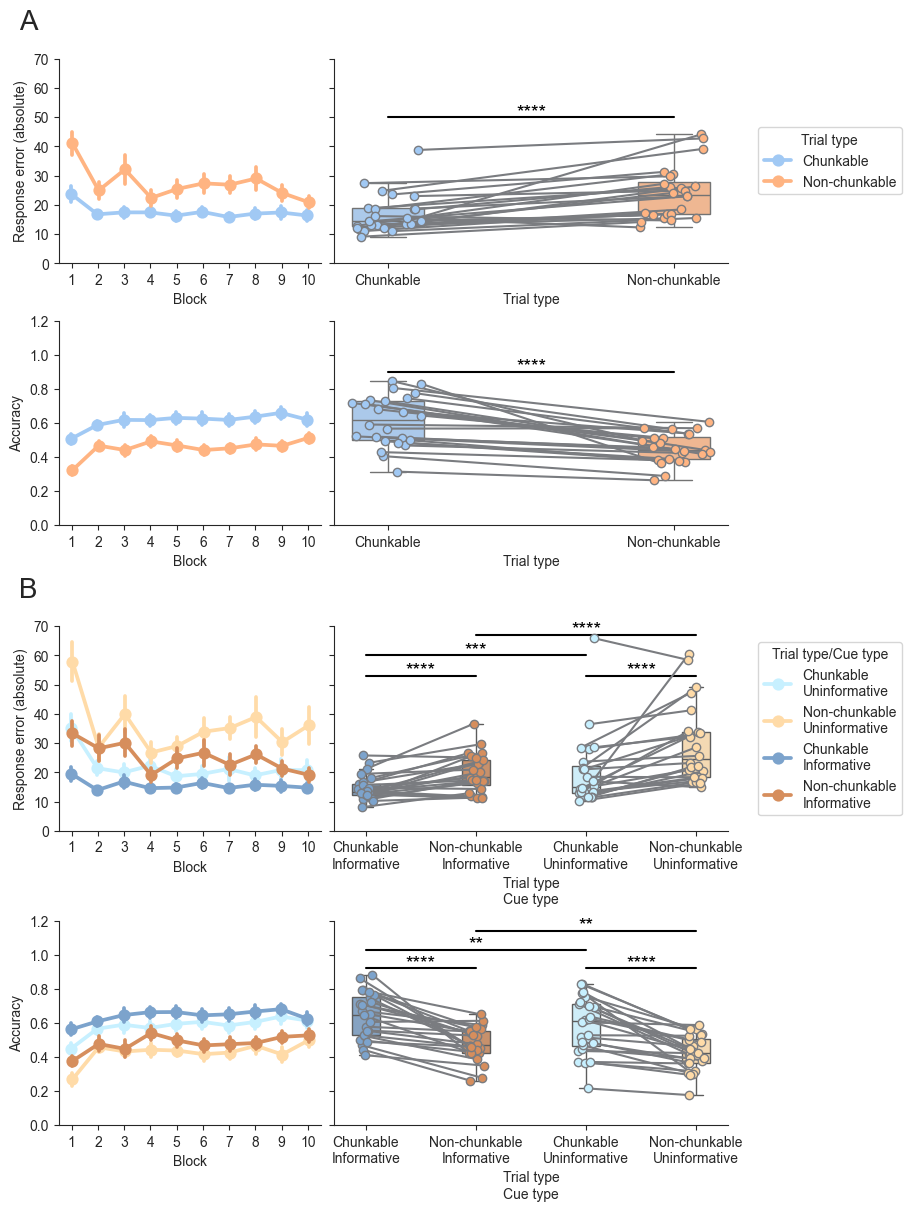

In [23]:
# Create the figure
fig,ax = pyplot.subplots(4,3,figsize=(9,12),constrained_layout=True,
                         gridspec_kw={'width_ratios':[1,1.5,0.4],'height_ratios':[1,1,1,1],
                                      'wspace':0,'hspace':0})
seaborn.set_style('ticks')

# Ax0,0: effect of chunking over time (abs error)
seaborn.pointplot(ax=ax[0,0],
                  data=errNoCueDataOverTime,
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax[0,0].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax[0,0].text(-2,80,'A',fontsize=20)

# Ax0,1: effect of chunking (abs error)
jlib.display.pairedObs.boxPlotPaired(ax=ax[0,1],
                                     data=errNoCueData,
                                     x='Trial type',y='Response error (absolute)',
                                     width=0.25,palette=paletteBase)
ax[0,1].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax[0,1].tick_params(axis='y',which='both',labelleft=False)
ax[0,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[0,1],[0,1],50*numpy.array([1,1]),size=significanceSize,
                                               p=errChunkingTtestPS['ttest']['p'].to_numpy()[0])

# Ax0,2: legend hotfix :)
handles,labels = ax[0,0].get_legend_handles_labels()
ax[0,2].legend(handles=handles,labels=labels,title='Trial type',loc='center left')
ax[0,0].legend().set_visible(False)
ax[0,2].axis('off')

# Ax1,0: effect of chunking over time (accuracy)
seaborn.pointplot(ax=ax[1,0],
                  data=accNoCueDataOverTime,
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteBase)
ax[1,0].set_ylim(minAccuracyValue,maxAccuracyValue)

# Ax1,1: effect of chunking (accuracy)
jlib.display.pairedObs.boxPlotPaired(ax=ax[1,1],
                                     data=accNoCueData,
                                     x='Trial type',y='Accuracy',
                                     width=0.25,palette=paletteBase)
ax[1,1].set_ylim(minAccuracyValue,maxAccuracyValue)
ax[1,1].tick_params(axis='y',which='both',labelleft=False)
ax[1,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[1,1],[0,1],0.9*numpy.array([1,1]),size=significanceSize,
                                               p=accChunkingTtestPS['ttest']['p'].to_numpy()[0])

# Ax2,0: effect of chunking x cue over time (abs error)
seaborn.pointplot(ax=ax[2,0],
                  data=errOverTime.loc[errOverTime['Cue type']=='Uninformative',:],
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,legend=True,estimator=numpy.nanmean,palette=paletteUninformative)
seaborn.pointplot(ax=ax[2,0],
                  data=errOverTime.loc[errOverTime['Cue type']=='Informative',:],
                  x='Block',y='Response error (absolute)',hue='Trial type',
                  errorbar='se',dodge=True,legend=True,estimator=numpy.nanmean,palette=paletteInformative)
ax[2,0].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax[2,0].text(-2,80,'B',fontsize=20)

# Ax2,1: effect of chunking x cue (abs error)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[2,1],
                                            data=allParticipantData.groupby(['Subject','Trial type',
                                                                             'Cue type']).median().reset_index(),
                                            y='Response error (absolute)',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax[2,1].set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
ax[2,1].tick_params(axis='y',which='both',labelleft=False)
ax[2,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[2,1],[0,1],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[2,1],[2,3],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[2,1],[0,2],60*numpy.array([1,1]),size=significanceSize,
                                               p=2*errCTrialTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[2,1],[1,3],67*numpy.array([1,1]),size=significanceSize,
                                               p=2*errNCTrialTtestPS['ttest']['p'].to_numpy()[0])


# Ax2,2: another legend hotfix~
handles, labels = ax[2,0].get_legend_handles_labels()
if len(handles) > 0 and labels[0] in ['Trial type', '']:
    handles, labels = handles[1:], labels[1:]
custom_labels = ['Chunkable\nUninformative','Non-chunkable\nUninformative',
                 'Chunkable\nInformative','Non-chunkable\nInformative']
ax[2,2].legend(handles=handles,labels=custom_labels,title='Trial type/Cue type',loc='center left')
ax[2,0].legend().set_visible(False)
ax[2,2].axis('off')

# Ax3,0: effect of chunking x cue over time (accuracy)
seaborn.pointplot(ax=ax[3,0],
                  data=allParticipantData.loc[allParticipantData['Cue type']=='Uninformative',
                                              :].groupby(['Subject','Block',
                                                          'Trial type','Cue type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteUninformative)
seaborn.pointplot(ax=ax[3,0],
                  data=allParticipantData.loc[allParticipantData['Cue type']=='Informative',
                                              :].groupby(['Subject','Block',
                                                          'Trial type','Cue type']).mean().reset_index(),
                  x='Block',y='Accuracy',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteInformative)
ax[3,0].set_ylim(minAccuracyValue,maxAccuracyValue)

# Ax3,1: effect of chunking x cue (accuracy)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[3,1],
                                            data=allParticipantData.groupby(['Subject','Trial type',
                                                                             'Cue type']).mean().reset_index(),
                                            y='Accuracy',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax[3,1].set_ylim(minAccuracyValue,maxAccuracyValue)
ax[3,1].tick_params(axis='y',which='both',labelleft=False)
ax[3,1].set_ylabel("")
jlib.display.utils.displayPairwiseSignificance(ax[3,1],[0,1],0.92*numpy.array([1,1]),size=significanceSize,
                                               p=2*accICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[3,1],[2,3],0.92*numpy.array([1,1]),size=significanceSize,
                                               p=2*accUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[3,1],[0,2],1.03*numpy.array([1,1]),size=significanceSize,
                                               p=2*accCTrialTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[3,1],[1,3],1.14*numpy.array([1,1]),size=significanceSize,
                                               p=2*accNCTrialTtestPS['ttest']['p'].to_numpy()[0])

# More legend hotfixes
ax[1,2].axis('off')
ax[3,2].axis('off')

seaborn.despine()

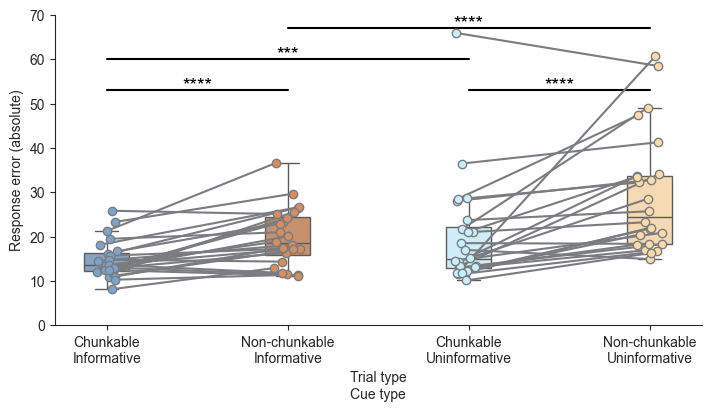

In [24]:
# Create the figure
fig,ax = pyplot.subplots(1,1,figsize=(7,4),constrained_layout=True)
seaborn.set_style('ticks')

# Ax0,1: effect of chunking x cue (abs error)
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax,
                                            data=allParticipantData.groupby(['Subject','Trial type',
                                                                             'Cue type']).median().reset_index(),
                                            y='Response error (absolute)',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax.set_ylim(minErrorOverBlocksValue,maxErrorOverBlocksValue)
jlib.display.utils.displayPairwiseSignificance(ax,[0,1],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[2,3],53*numpy.array([1,1]),size=significanceSize,
                                               p=2*errUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[0,2],60*numpy.array([1,1]),size=significanceSize,
                                               p=2*errCTrialTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax,[1,3],67*numpy.array([1,1]),size=significanceSize,
                                               p=2*errNCTrialTtestPS['ttest']['p'].to_numpy()[0])

seaborn.despine()

# if saveFigs:
#     for format in imageFormats:
#         fig.savefig(imagePath+'responseChunkingAndCue.'+format,format=format,dpi=1200)